In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
H = pd.read_csv('./subject_H_cross_validation_result_sENG-6class.csv')
B = pd.read_csv('./subject_BY_cross_validation_result_sENG-6class.csv')
M = pd.read_csv('./subject_MJ_cross_validation_result_sENG-6class.csv')

amp1 = pd.read_csv('./Amputee-iENG-S2-cross-val-6class.csv')
amp2 = pd.read_csv('./Amputee-iENG-S3-cross-val-6class.csv')

In [6]:
def heatmap_confusion_matrix(cms, class_names):
    cm_mean = np.mean(cms, axis=0)
    cm_std = np.std(cms, axis=0)

    # Format annotations as mean ± std (2 decimals)
    annot = np.empty_like(cm_mean, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            annot[i, j] = f"{cm_mean[i, j]:.1f}\n±({cm_std[i, j]:.1f})"

    # Plot heatmap
    plt.figure(figsize=(6, 6), dpi=350)
    sns.heatmap(cm_mean, annot=annot, fmt='', cmap='Reds', cbar=False,
                xticklabels=class_names if class_names else range(cm_mean.shape[0]),
                yticklabels=class_names if class_names else range(cm_mean.shape[0]),
                annot_kws={"fontsize": 13})

    label_size = 15
    plt.xlabel('Predicted Label', fontsize=label_size)
    plt.ylabel('True Label', fontsize=label_size)
    plt.title('Confusion Matrix (Mean ± Std)', fontsize=18)
    plt.tight_layout()
    plt.show()

    # Compute overall accuracy (mean of accuracies, not ratio of means)
    accs = [np.trace(cm) / np.sum(cm) for cm in cms]
    mean_acc, std_acc = np.mean(accs), np.std(accs)
    print(f"Overall Accuracy: {mean_acc:.4f} ± {std_acc:.4f} "
          f"({mean_acc*100:.2f}% ± {std_acc*100:.2f}%)")

    return cm_mean, cm_std, mean_acc, std_acc

In [13]:
def heatmap_confusion_matrix_with_norm(cms, class_names, normalize):
    # Optionally normalize each confusion matrix
    cms_to_use = []
    for cm in cms:
        cm_np = cm.values if isinstance(cm, pd.DataFrame) else cm
        if normalize:
            row_sums = cm_np.sum(axis=1, keepdims=True)  # now works
            cm_norm = cm_np / row_sums
            cms_to_use.append(cm_norm)
        else:
            cms_to_use.append(cm_np)

    cms_to_use = np.array(cms_to_use)

    # Compute mean and std
    cm_mean = np.mean(cms_to_use, axis=0)
    cm_std = np.std(cms_to_use, axis=0)

    # Format annotations as mean ± std (2 decimals)
    annot = np.empty_like(cm_mean, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            annot[i, j] = f"{cm_mean[i, j]:.2f}\n±{cm_std[i, j]:.2f}"

    # Plot heatmap
    plt.figure(figsize=(6, 6), dpi=350)
    sns.heatmap(cm_mean, annot=annot, fmt='', cmap='Reds', cbar=False,
                xticklabels=class_names if class_names else range(cm_mean.shape[0]),
                yticklabels=class_names if class_names else range(cm_mean.shape[0]),
                annot_kws={"fontsize": 13})

    label_size = 15
    plt.xlabel('Predicted Label', fontsize=label_size)
    plt.ylabel('True Label', fontsize=label_size)
    title = 'Confusion Matrix (Normalized Mean ± Std)' if normalize else 'Confusion Matrix (Mean ± Std)'
    #plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.show()

    # Compute overall accuracy (mean of accuracies)
    if normalize:
        accs = [np.trace(cm) / cm.shape[0] for cm in cms_to_use]  # row-wise normalized, mean diag
    else:
        accs = [np.trace(cm) / np.sum(cm) for cm in cms_to_use]
    mean_acc, std_acc = np.mean(accs), np.std(accs)
    print(f"Overall Accuracy: {mean_acc:.4f} ± {std_acc:.4f} "
          f"({mean_acc*100:.2f}% ± {std_acc*100:.2f}%)")

    return cm_mean, cm_std, mean_acc, std_acc

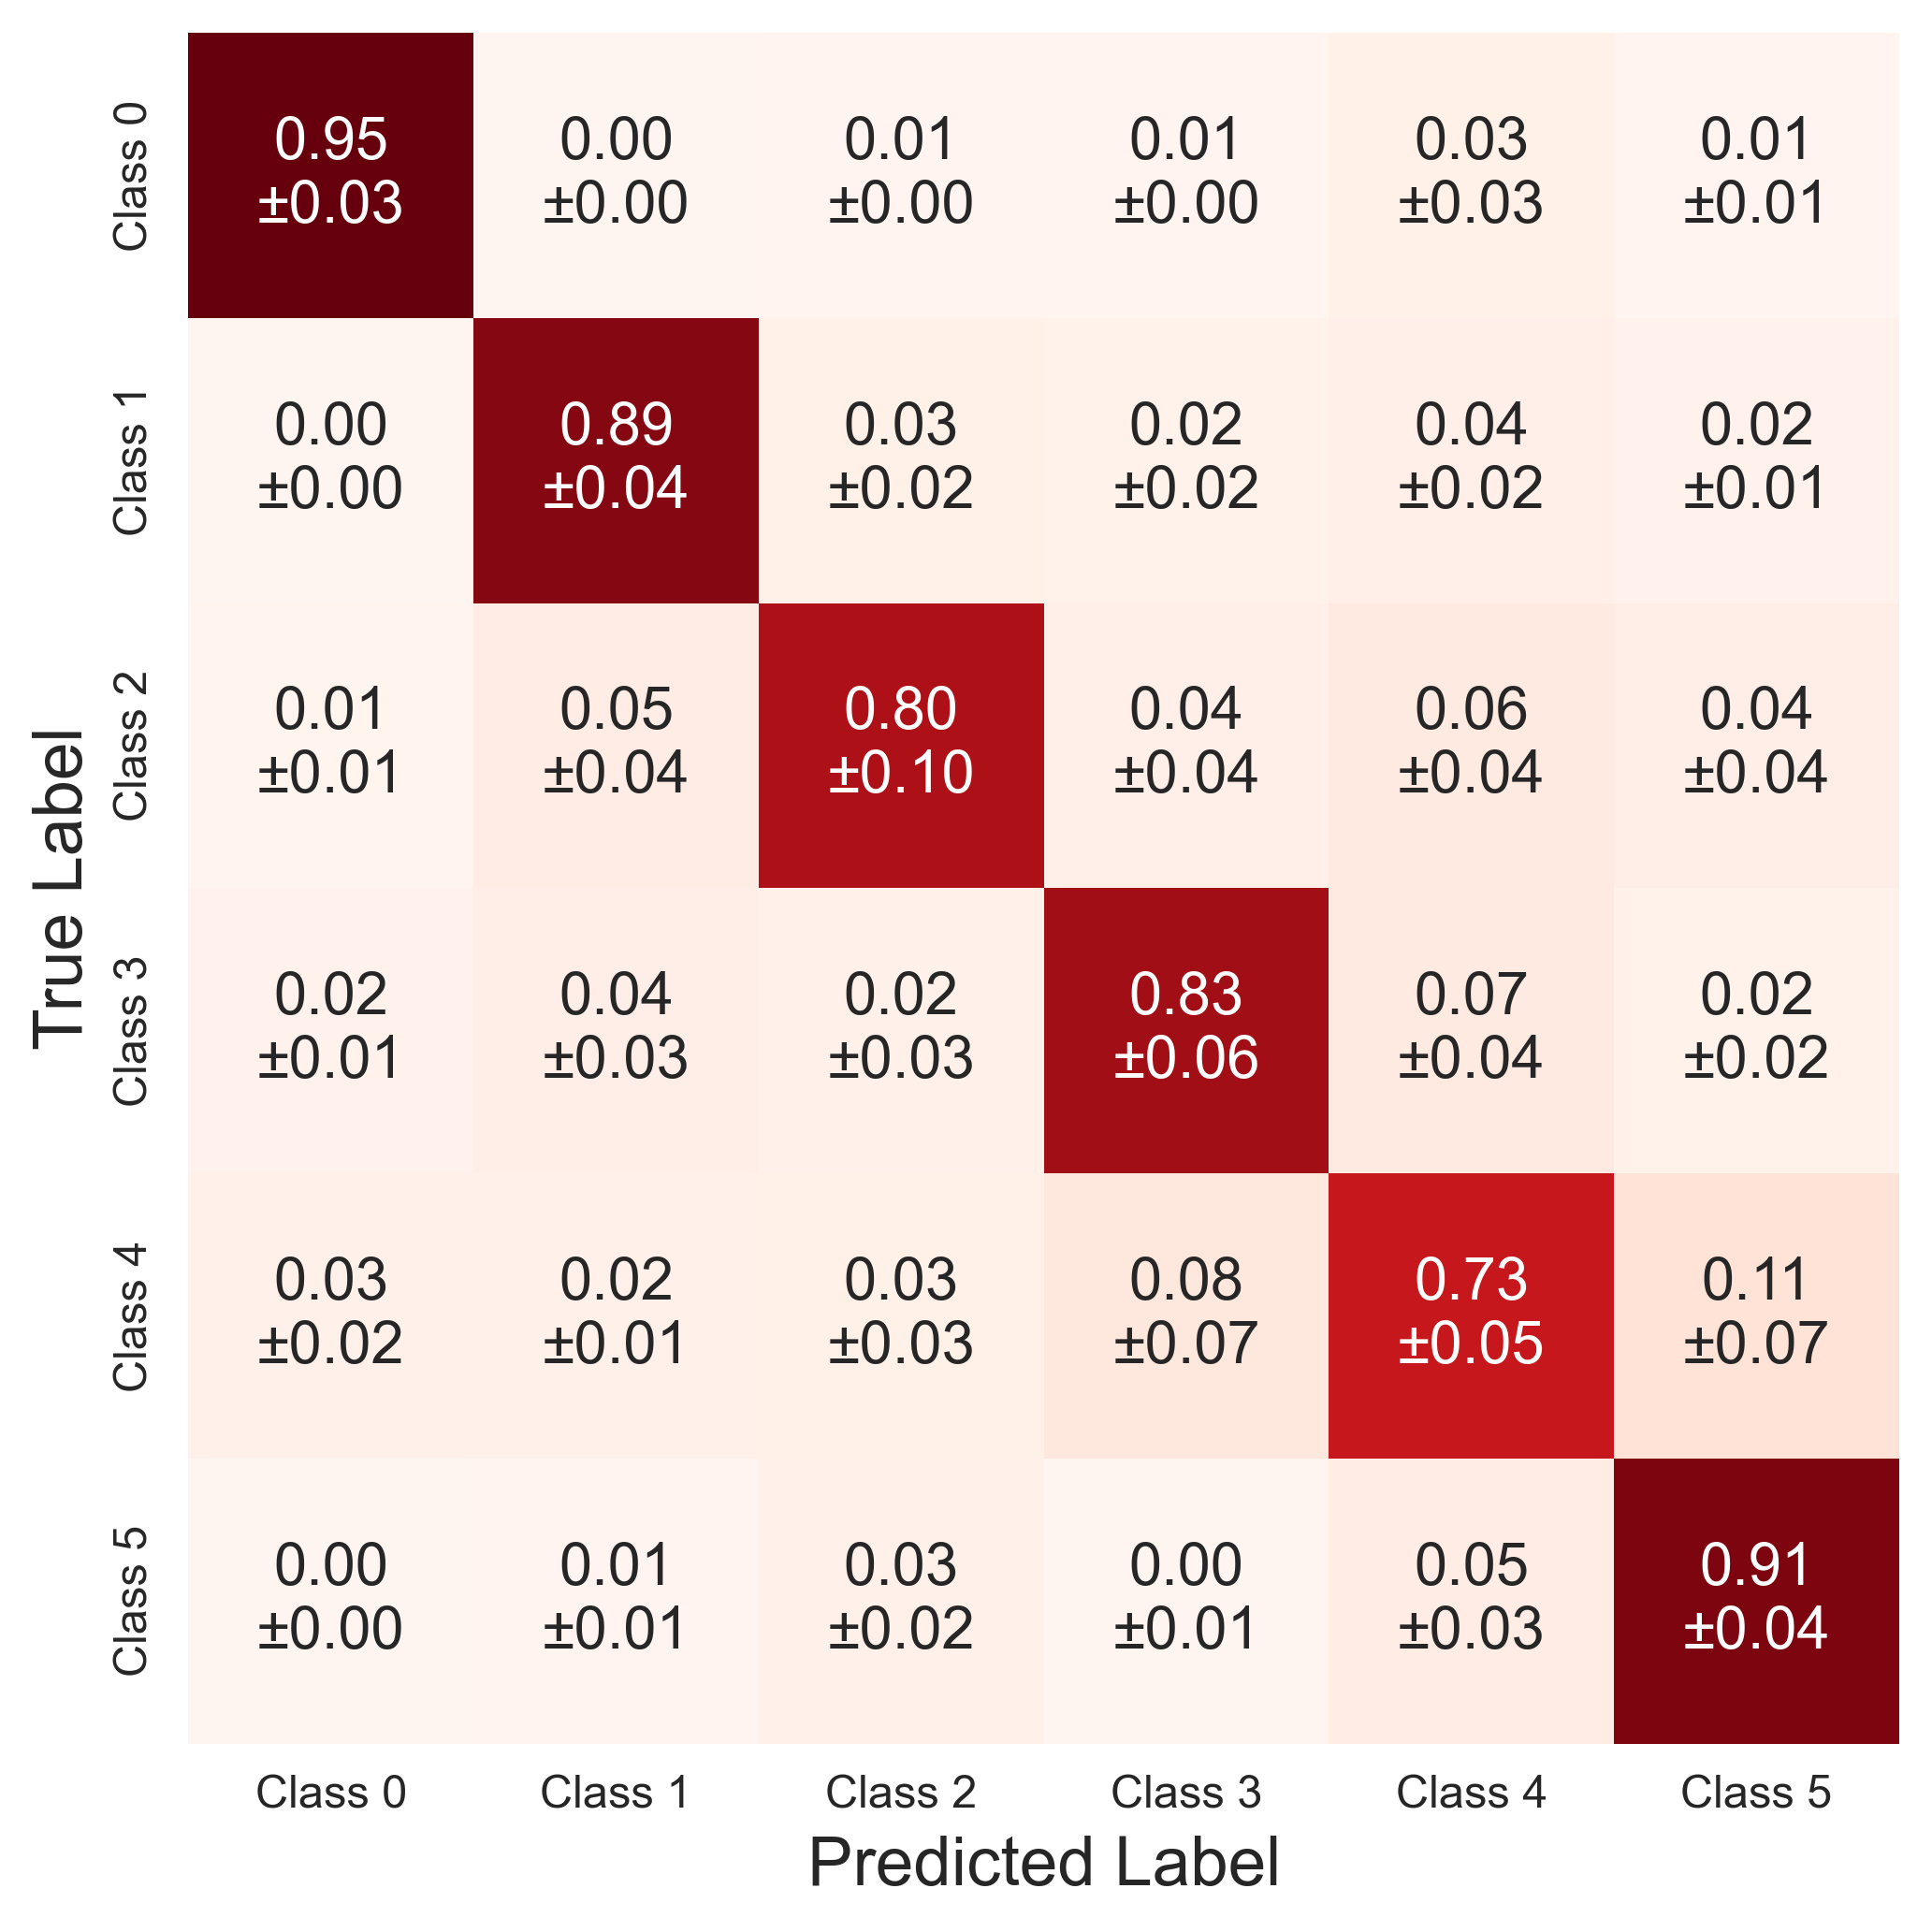

Overall Accuracy: 0.8506 ± 0.0475 (85.06% ± 4.75%)


In [14]:
cms = [H, B, M]  # list of confusion matrices
class_names = [f"Class {i}" for i in range(6)]
cm_mean, cm_std, mean_acc, std_acc = heatmap_confusion_matrix_with_norm(cms, class_names, normalize=True)

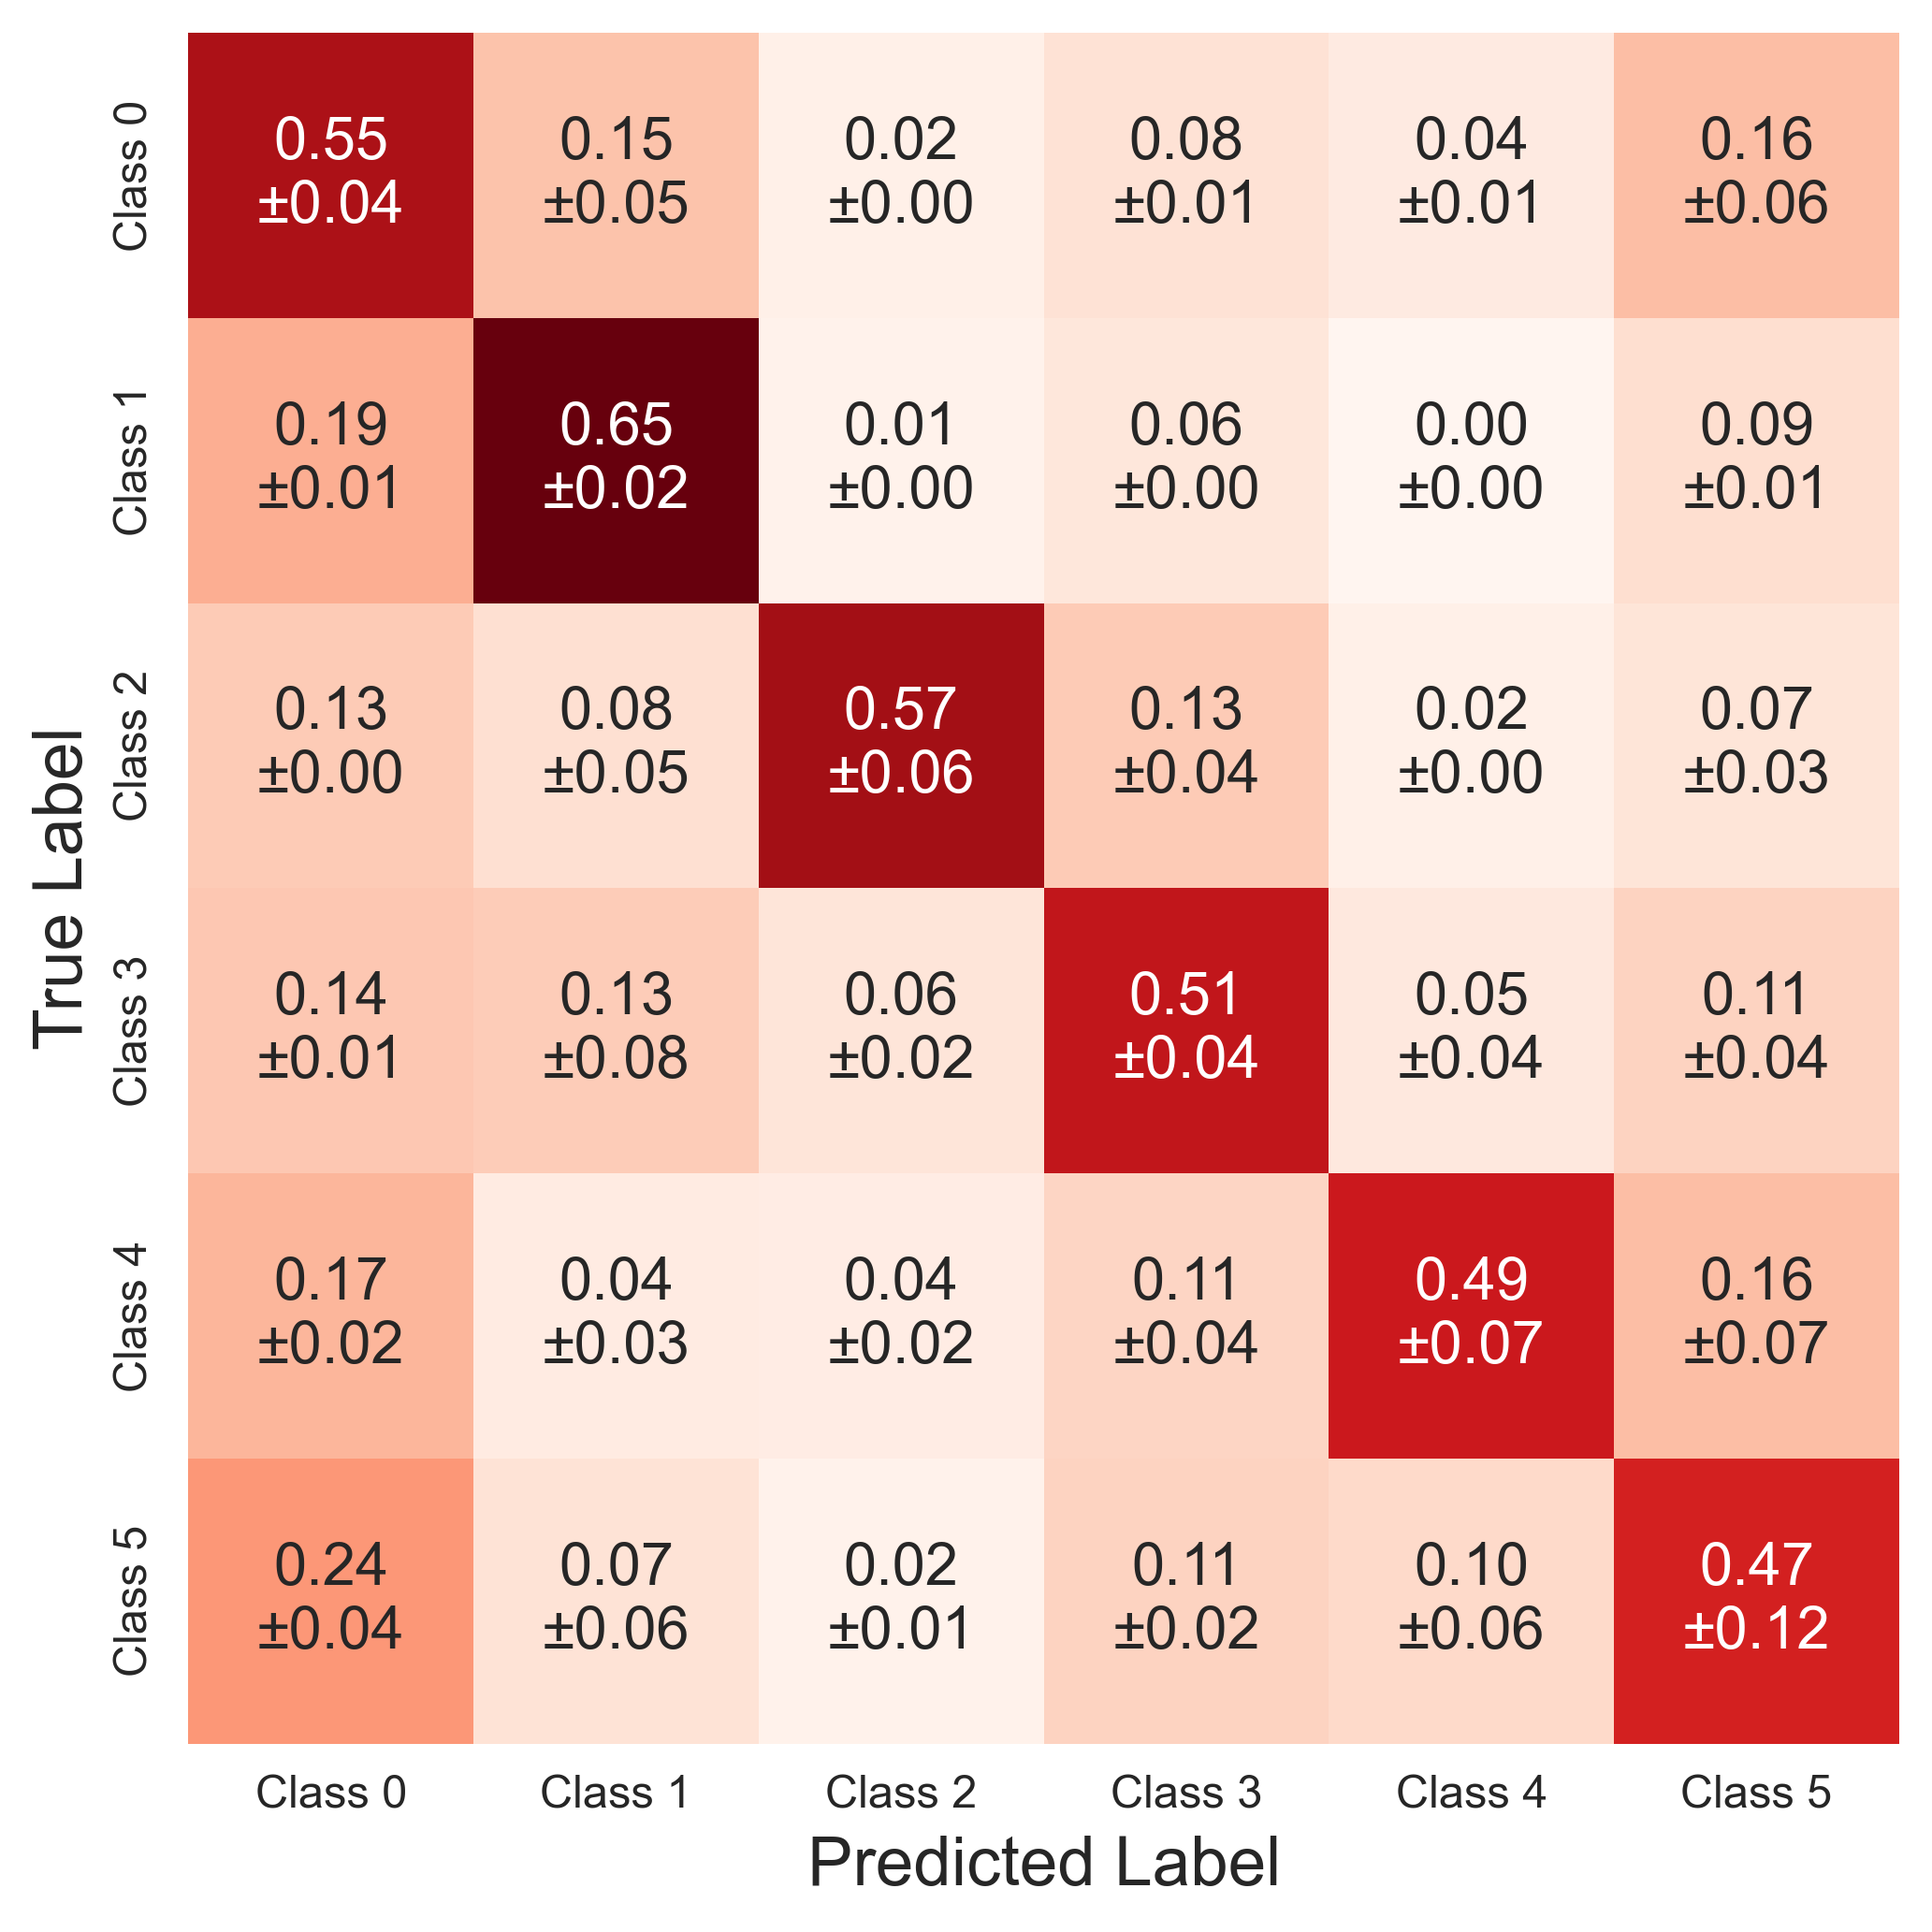

Overall Accuracy: 0.5406 ± 0.0200 (54.06% ± 2.00%)


In [15]:
cms = [amp1, amp2]  # list of confusion matrices
class_names = [f"Class {i}" for i in range(6)]
cm_mean, cm_std, mean_acc, std_acc = heatmap_confusion_matrix_with_norm(cms, class_names, normalize=True)

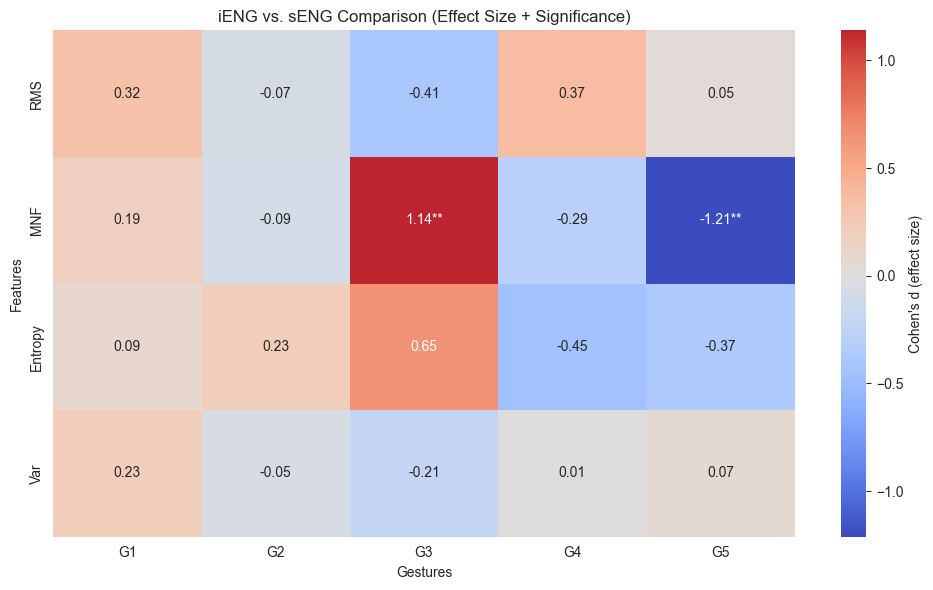

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Example dummy data
# ---------------------------
# Suppose we have 5 gestures × 4 features, across 10 subjects
n_subjects = 10
gestures = ["G1", "G2", "G3", "G4", "G5"]
features = ["RMS", "MNF", "Entropy", "Var"]

# Random example signals: shape = (subjects, gestures, features)
iENG = np.random.rand(n_subjects, len(gestures), len(features))
sENG = np.random.rand(n_subjects, len(gestures), len(features))

# ---------------------------
# Compute t-tests + effect sizes
# ---------------------------
p_values = np.zeros((len(features), len(gestures)))
effect_sizes = np.zeros((len(features), len(gestures)))

def cohens_d(x, y):
    diff = x - y
    return np.mean(diff) / np.std(diff, ddof=1)

for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        t_stat, p_val = ttest_rel(iENG[:, j, i], sENG[:, j, i])
        p_values[i, j] = p_val
        effect_sizes[i, j] = cohens_d(iENG[:, j, i], sENG[:, j, i])

# ---------------------------
# Convert to DataFrame for plotting
# ---------------------------
df_effect = pd.DataFrame(effect_sizes, index=features, columns=gestures)
df_pval = pd.DataFrame(p_values, index=features, columns=gestures)

# ---------------------------
# Function to add stars based on p-value
# ---------------------------
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Create annotations (effect size + stars)
annot = df_effect.round(2).astype(str)
for i in range(df_effect.shape[0]):
    for j in range(df_effect.shape[1]):
        star = significance_stars(df_pval.iloc[i, j])
        annot.iloc[i, j] = annot.iloc[i, j] + star

# ---------------------------
# Plot heatmap
# ---------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(df_effect, annot=annot, fmt="", cmap="coolwarm", center=0,
            cbar_kws={'label': "Cohen's d (effect size)"})
plt.title("iENG vs. sENG Comparison (Effect Size + Significance)")
plt.xlabel("Gestures")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


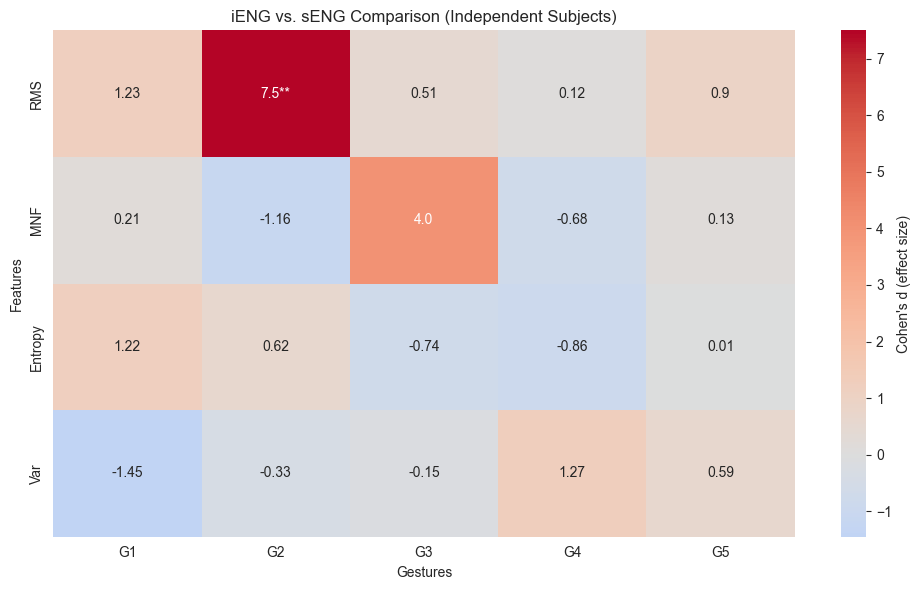

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_43928\2131532749.py:96: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.swarmplot(data=df_plot, x='Gesture', y='Value', hue='Modality', dodge=True, color='k', alpha=0.7)


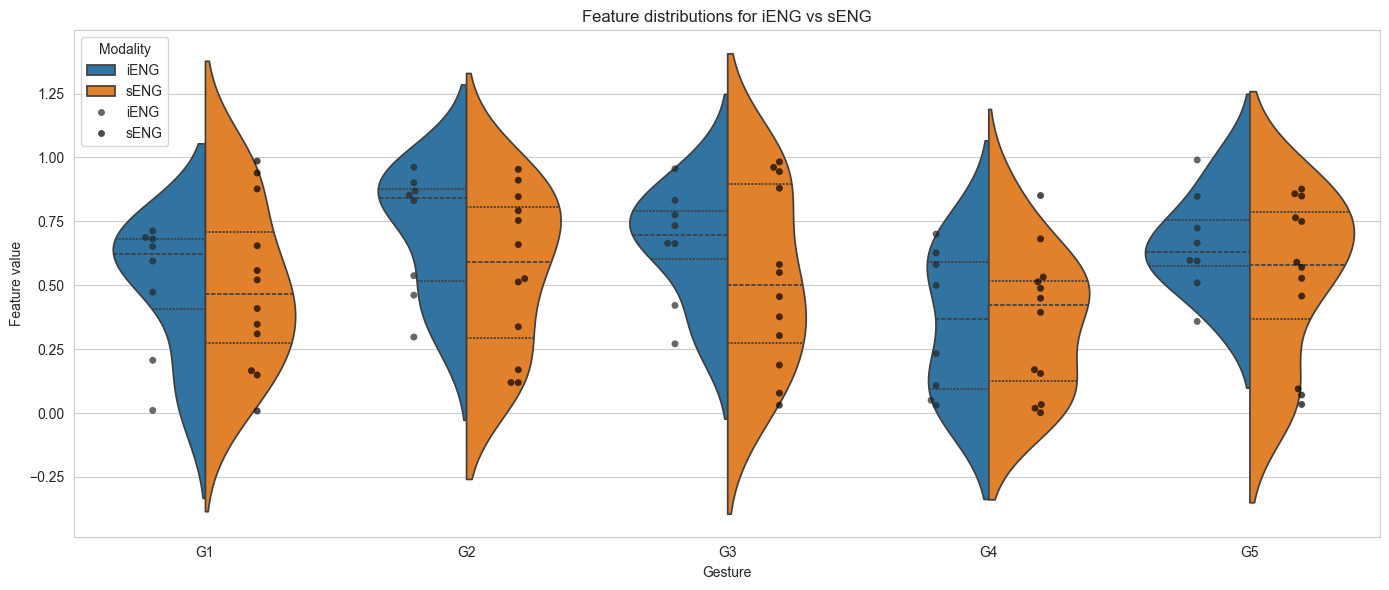

In [13]:
from scipy.stats import ttest_ind, mannwhitneyu

# ---------------------------
# Example dummy data
# ---------------------------
# Suppose we have 2 iENG subjects, 3 sENG subjects
# 5 gestures, 4 features
gestures = ["G1", "G2", "G3", "G4", "G5"]
features = ["RMS", "MNF", "Entropy", "Var"]

# Data shapes: (subjects, gestures, features)
iENG = np.random.rand(2, len(gestures), len(features))
sENG = np.random.rand(3, len(gestures), len(features))

# ---------------------------
# Helper: Cohen's d for independent samples
# ---------------------------
def cohens_d_independent(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# ---------------------------
# Compute t-tests and effect sizes
# ---------------------------
p_values = np.zeros((len(features), len(gestures)))
effect_sizes = np.zeros((len(features), len(gestures)))

for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        x = iENG[:, j, i]
        y = sENG[:, j, i]

        # Use independent t-test
        t_stat, p_val = ttest_ind(x, y, equal_var=False)  # Welch's t-test
        p_values[i, j] = p_val

        # Compute effect size
        effect_sizes[i, j] = cohens_d_independent(x, y)

# ---------------------------
# Convert to DataFrame for plotting
# ---------------------------
df_effect = pd.DataFrame(effect_sizes, index=features, columns=gestures)
df_pval = pd.DataFrame(p_values, index=features, columns=gestures)

# ---------------------------
# Significance stars
# ---------------------------
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Create annotation: effect size + stars
annot = df_effect.round(2).astype(str)
for i in range(df_effect.shape[0]):
    for j in range(df_effect.shape[1]):
        star = significance_stars(df_pval.iloc[i, j])
        annot.iloc[i, j] = annot.iloc[i, j] + star

# ---------------------------
# Heatmap plot
# ---------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(df_effect, annot=annot, fmt='', cmap="coolwarm", center=0,
            cbar_kws={'label': "Cohen's d (effect size)"})
plt.title("iENG vs. sENG Comparison (Independent Subjects)")
plt.xlabel("Gestures")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# ---------------------------
# Optional: violin + swarm plot for individual features
# ---------------------------
# Combine data for plotting
plot_data = []
for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        for val in iENG[:, j, i]:
            plot_data.append([gest, feat, 'iENG', val])
        for val in sENG[:, j, i]:
            plot_data.append([gest, feat, 'sENG', val])

df_plot = pd.DataFrame(plot_data, columns=['Gesture', 'Feature', 'Modality', 'Value'])

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_plot, x='Gesture', y='Value', hue='Modality', split=True, inner='quartile')
sns.swarmplot(data=df_plot, x='Gesture', y='Value', hue='Modality', dodge=True, color='k', alpha=0.7)
plt.title("Feature distributions for iENG vs sENG")
plt.ylabel("Feature value")
plt.legend(title='Modality')
plt.tight_layout()
plt.show()


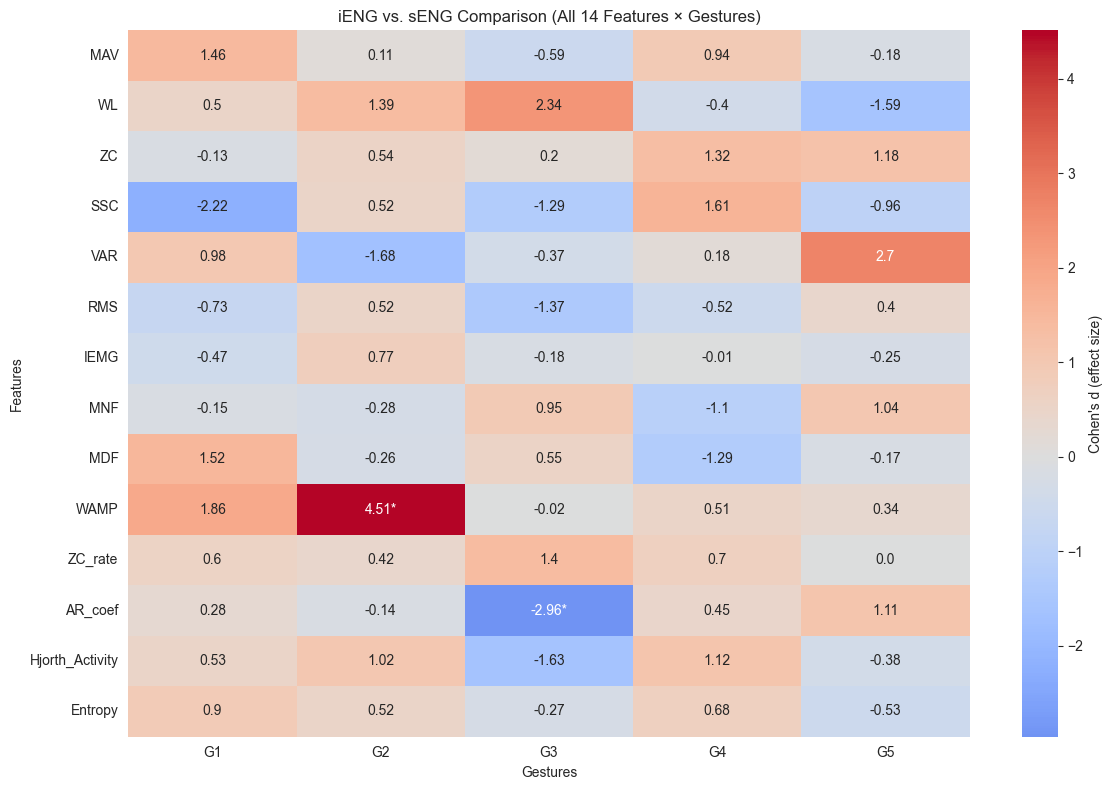

C:\Users\hml76\PycharmProjects\TNSE-R1\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\hml76\PycharmProjects\TNSE-R1\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\hml76\PycharmProjects\TNSE-R1\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\hml76\PycharmProjects\TNSE-R1\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0.

AttributeError: 'NoneType' object has no attribute 'remove'

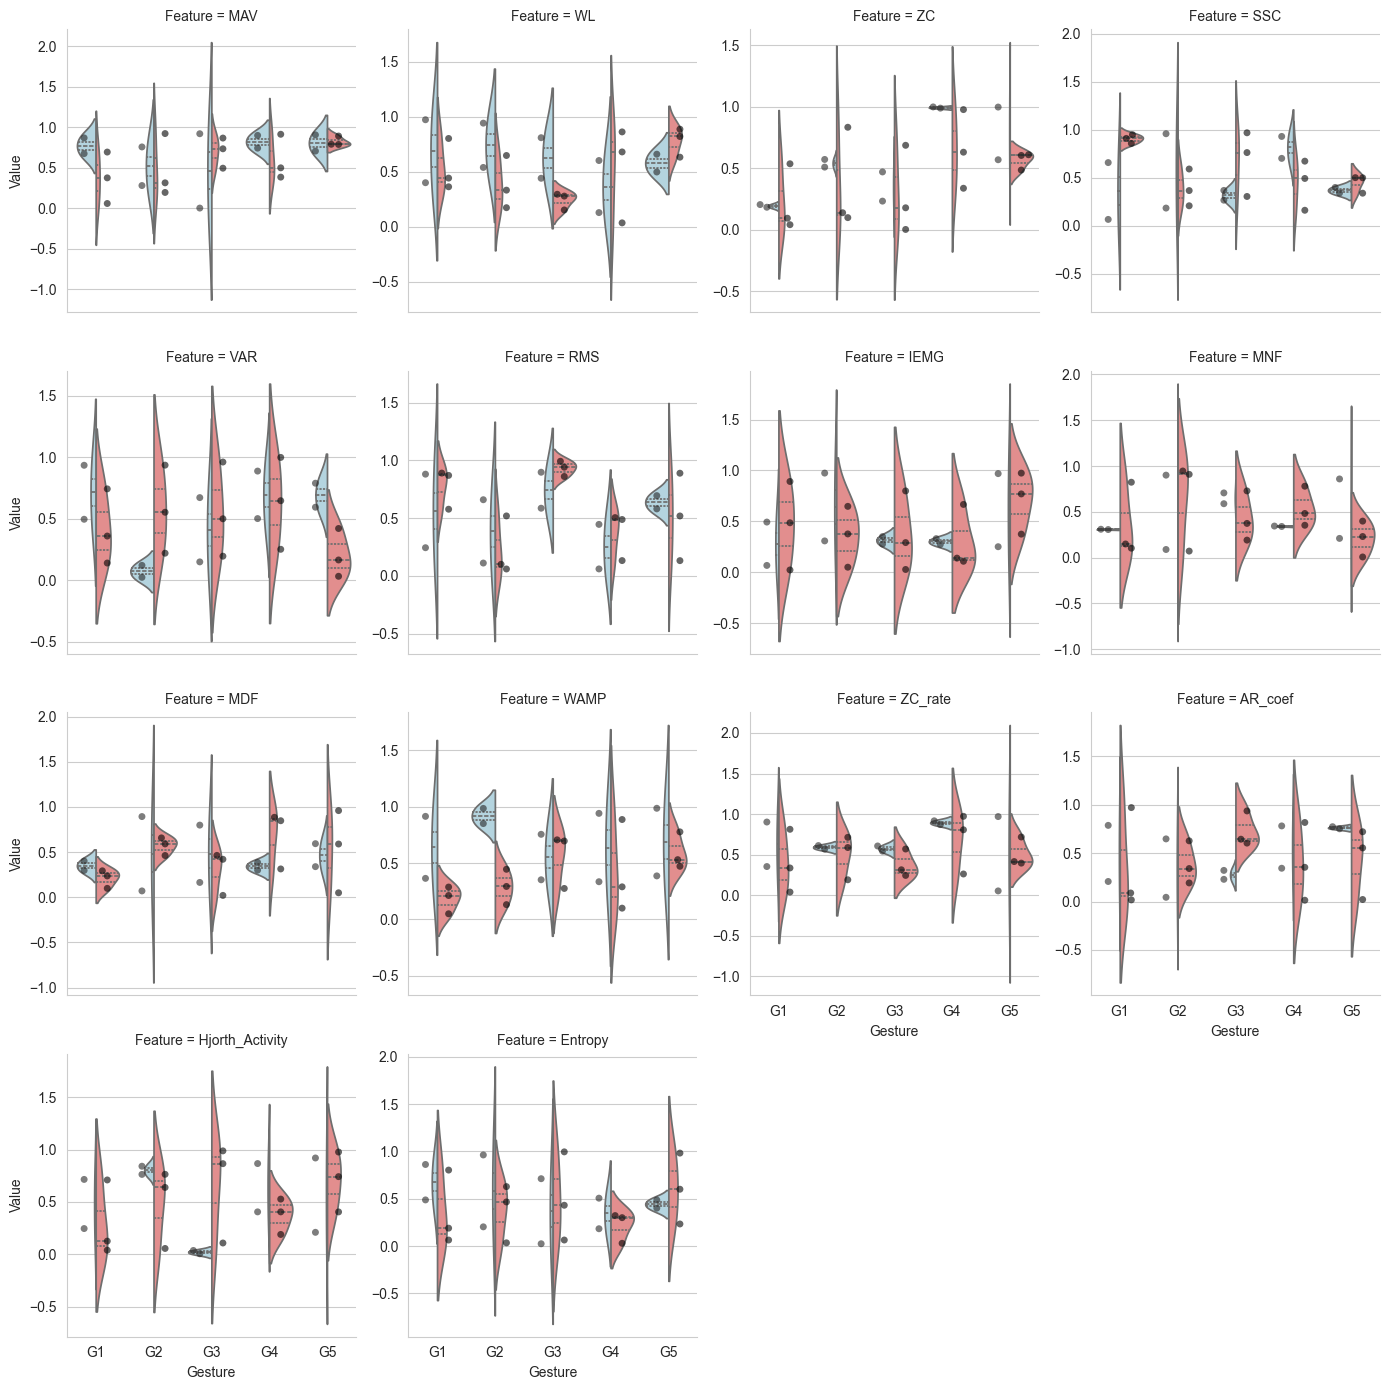

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Example dummy data
# ---------------------------
# 2 iENG subjects, 3 sENG subjects, 5 gestures, 14 features
gestures = ["G1", "G2", "G3", "G4", "G5"]
features = ["MAV", "WL", "ZC", "SSC", "VAR", "RMS", "IEMG", "MNF",
            "MDF", "WAMP", "ZC_rate", "AR_coef", "Hjorth_Activity", "Entropy"]

# Random data shape: (subjects, gestures, features)
iENG = np.random.rand(2, len(gestures), len(features))
sENG = np.random.rand(3, len(gestures), len(features))

# ---------------------------
# Helper: Cohen's d for independent samples
# ---------------------------
def cohens_d_independent(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# ---------------------------
# Compute t-tests and effect sizes
# ---------------------------
p_values = np.zeros((len(features), len(gestures)))
effect_sizes = np.zeros((len(features), len(gestures)))

for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        x = iENG[:, j, i]
        y = sENG[:, j, i]

        # Independent t-test (Welch)
        t_stat, p_val = ttest_ind(x, y, equal_var=False)
        p_values[i, j] = p_val

        # Cohen's d
        effect_sizes[i, j] = cohens_d_independent(x, y)

# ---------------------------
# Convert to DataFrame for plotting
# ---------------------------
df_effect = pd.DataFrame(effect_sizes, index=features, columns=gestures)
df_pval = pd.DataFrame(p_values, index=features, columns=gestures)

# ---------------------------
# Significance stars
# ---------------------------
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

annot = df_effect.round(2).astype(str)
for i in range(df_effect.shape[0]):
    for j in range(df_effect.shape[1]):
        star = significance_stars(df_pval.iloc[i, j])
        annot.iloc[i, j] = annot.iloc[i, j] + star

# ---------------------------
# Heatmap
# ---------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(df_effect, annot=annot, fmt='', cmap="coolwarm", center=0,
            cbar_kws={'label': "Cohen's d (effect size)"})
plt.title("iENG vs. sENG Comparison (All 14 Features × Gestures)")
plt.xlabel("Gestures")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# ---------------------------
# Violin + Swarm plots for all features
# ---------------------------
plot_data = []
for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        for val in iENG[:, j, i]:
            plot_data.append([gest, feat, 'iENG', val])
        for val in sENG[:, j, i]:
            plot_data.append([gest, feat, 'sENG', val])

df_plot = pd.DataFrame(plot_data, columns=['Gesture', 'Feature', 'Modality', 'Value'])

# Faceted violin plot using seaborn's FacetGrid
g = sns.FacetGrid(df_plot, col="Feature", col_wrap=4, sharey=False, height=3.5)
g.map_dataframe(sns.violinplot, x="Gesture", y="Value", hue="Modality", split=True, inner="quartile", palette=["lightblue","lightcoral"])
g.map_dataframe(sns.swarmplot, x="Gesture", y="Value", hue="Modality", dodge=True, color='k', alpha=0.6)

# Remove duplicate legends
for ax in g.axes.flatten():
    ax.legend_.remove()
g.add_legend(title="Modality")
plt.tight_layout()
plt.show()
